# Top Trumps Balancing - Automatische Hyperparameter-Optimierung

## Optuna-basiertes Hyperparameter-Tuning für Evolutionäre Algorithmen

Dieses Notebook nutzt **Optuna** zur automatischen Optimierung der Hyperparameter von NSGA-II.

**Warum Optuna?**
- Bayesian Optimization mit Tree-Parzen Estimator (TPE)
- Einfache Integration mit pymoo
- Integriertes Dashboard zur Visualisierung
- Pruning für frühe Abbrüche schlechter Trials

**Optimierte Hyperparameter:**
- `pop_size`: Populationsgröße (20-100)
- `eta_crossover`: SBX-Crossover Parameter (5-30)
- `eta_mutation`: Polynomial Mutation Parameter (5-30)
- `crossover_prob`: Crossover-Wahrscheinlichkeit (0.6-1.0)

**Zielmetrik:** Hypervolume (maximieren)

---

## 1. Setup & Installation

In [1]:
%pip install numpy pymoo pandas matplotlib seaborn optuna plotly kaleido --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Optuna
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_contour
)

# Pymoo
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.algorithms.moo.sms import SMSEMOA
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.indicators.hv import HV
from pymoo.util.ref_dirs import get_reference_directions

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print(f"Optuna Version: {optuna.__version__}")

Optuna Version: 4.7.0


In [3]:
# Konfiguration laden
RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")

with open(RESULTS_DIR / 'config.json', 'r') as f:
    CONFIG = json.load(f)

SEED = CONFIG['seed']
K = CONFIG['K']
L = CONFIG['L']
XL = CONFIG['xl']
XU = CONFIG['xu']

def set_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)

print("Konfiguration geladen:")
print(f"  K={K}, L={L}, Seed={SEED}")

Konfiguration geladen:
  K=22, L=4, Seed=42


---

## 2. Simulation & Problem Definition

In [4]:
from simulation import TopTrumpsSimulation, TopTrumpsBalancing, evaluate_deck_detailed

sim = TopTrumpsSimulation(num_cards=K, num_categories=L)
print(f"Simulation erstellt: {K} Karten, {L} Kategorien")

Simulation erstellt: 22 Karten, 4 Kategorien


---

## 3. Optuna Konfiguration

### Hyperparameter-Suchraum

| Parameter | Bereich | Beschreibung |
|-----------|---------|---------------|
| `pop_size` | [20, 100] | Populationsgröße |
| `eta_crossover` | [5, 30] | SBX Distribution Index |
| `eta_mutation` | [5, 30] | PM Distribution Index |
| `crossover_prob` | [0.6, 1.0] | Crossover-Wahrscheinlichkeit |

In [5]:
# Optuna Tuning Konfiguration
N_TRIALS = 30           # Anzahl der Hyperparameter-Konfigurationen
N_GEN = 40              # Generationen pro Trial (reduziert für schnelleres Tuning)
R_SIMULATIONS = 500     # Simulationen pro Evaluation (reduziert für schnelleres Tuning)
TUNING_SEEDS = [42, 101, 202]  # Seeds für robuste Bewertung

print(f"Optuna Konfiguration:")
print(f"  Trials: {N_TRIALS}")
print(f"  Generationen pro Trial: {N_GEN}")
print(f"  Seeds für Evaluation: {TUNING_SEEDS}")

Optuna Konfiguration:
  Trials: 30
  Generationen pro Trial: 40
  Seeds für Evaluation: [42, 101, 202]


---

## 4. Optuna Objective Function

Die Objective Function:
1. Sampelt Hyperparameter aus dem Suchraum
2. Erstellt NSGA-II mit diesen Parametern
3. Führt Optimierung mit mehreren Seeds durch
4. Berechnet durchschnittlichen Hypervolume
5. Gibt diesen als Zielwert zurück

In [6]:
def objective(trial):
    """
    Optuna Objective Function für NSGA-II Hyperparameter-Tuning.
    
    Returns:
        float: Durchschnittlicher Hypervolume über mehrere Seeds (zu maximieren)
    """
    # Hyperparameter sampeln
    pop_size = trial.suggest_int("pop_size", 20, 100, step=10)
    eta_crossover = trial.suggest_float("eta_crossover", 5.0, 30.0)
    eta_mutation = trial.suggest_float("eta_mutation", 5.0, 30.0)
    crossover_prob = trial.suggest_float("crossover_prob", 0.6, 1.0)
    
    # Problem erstellen (mit reduzierten Simulationen für schnelleres Tuning)
    problem = TopTrumpsBalancing(sim, n_simulations=R_SIMULATIONS, xl=XL, xu=XU)
    termination = get_termination("n_gen", N_GEN)
    
    hvs = []
    
    for seed in TUNING_SEEDS:
        set_seeds(seed)
        
        # Algorithmus mit gesampelten Hyperparametern erstellen
        algorithm = NSGA2(
            pop_size=pop_size,
            sampling=FloatRandomSampling(),
            crossover=SBX(prob=crossover_prob, eta=eta_crossover),
            mutation=PM(eta=eta_mutation),
            eliminate_duplicates=True
        )
        
        # Optimierung durchführen
        res = minimize(problem, algorithm, termination, seed=seed, verbose=False)
        
        # Hypervolume berechnen
        hv = HV(ref_point=np.array([0.0, 0.0]))(res.F)
        hvs.append(hv)
        
        # Pruning: Früher Abbruch wenn HV zu schlecht
        trial.report(np.mean(hvs), len(hvs) - 1)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(hvs)

print("Objective Function definiert.")

Objective Function definiert.


---

## 5. Hyperparameter-Optimierung starten

**Hinweis:** Dieser Schritt kann 30-60 Minuten dauern (abhängig von Hardware und N_TRIALS).

In [7]:
# Optuna Study erstellen
sampler = optuna.samplers.TPESampler(seed=SEED)  # Tree-Parzen Estimator
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)

study = optuna.create_study(
    study_name="nsga2_hyperparameter_tuning",
    direction="maximize",  # Hypervolume maximieren
    sampler=sampler,
    pruner=pruner
)

print("Starte Hyperparameter-Optimierung...")
print(f"  Sampler: TPE (Tree-Parzen Estimator)")
print(f"  Pruner: MedianPruner")
print(f"  Richtung: Maximize (Hypervolume)")
print("="*60)

[I 2026-01-30 12:02:50,195] A new study created in memory with name: nsga2_hyperparameter_tuning


Starte Hyperparameter-Optimierung...
  Sampler: TPE (Tree-Parzen Estimator)
  Pruner: MedianPruner
  Richtung: Maximize (Hypervolume)


In [8]:
%%time

# Optimierung durchführen
study.optimize(
    objective, 
    n_trials=N_TRIALS, 
    show_progress_bar=True,
    gc_after_trial=True  # Garbage Collection nach jedem Trial
)

print("\n" + "="*60)
print("Optimierung abgeschlossen!")

Best trial: 0. Best value: 3.0298:   3%|▎         | 1/30 [01:09<33:21, 69.02s/it]

[I 2026-01-30 12:03:59,242] Trial 0 finished with value: 3.029804 and parameters: {'pop_size': 50, 'eta_crossover': 28.767857660247905, 'eta_mutation': 23.299848545285126, 'crossover_prob': 0.8394633936788146}. Best is trial 0 with value: 3.029804.


Best trial: 0. Best value: 3.0298:   7%|▋         | 2/30 [01:48<24:10, 51.79s/it]

[I 2026-01-30 12:04:38,984] Trial 1 finished with value: 2.901968 and parameters: {'pop_size': 30, 'eta_crossover': 8.899863008405067, 'eta_mutation': 6.452090304204987, 'crossover_prob': 0.9464704583099741}. Best is trial 0 with value: 3.029804.


Best trial: 2. Best value: 3.53186:  10%|█         | 3/30 [03:22<31:57, 71.00s/it]

...

[I 2026-01-30 12:40:53,028] Trial 27 pruned. 


Best trial: 26. Best value: 3.56643:  97%|█████████▋| 29/30 [39:20<01:19, 79.04s/it]

[I 2026-01-30 12:42:10,834] Trial 28 pruned. 


Best trial: 26. Best value: 3.56643: 100%|██████████| 30/30 [41:06<00:00, 82.22s/it]

[I 2026-01-30 12:43:56,797] Trial 29 finished with value: 3.423318666666667 and parameters: {'pop_size': 80, 'eta_crossover': 29.208336093742137, 'eta_mutation': 21.322116732647178, 'crossover_prob': 0.834458846551644}. Best is trial 26 with value: 3.5664266666666666.

Optimierung abgeschlossen!
CPU times: user 40min 27s, sys: 22.2 s, total: 40min 49s
Wall time: 41min 6s


---

## 6. Ergebnisse analysieren

In [9]:
# Beste Konfiguration
print("=" * 60)
print("BESTE HYPERPARAMETER-KONFIGURATION")
print("=" * 60)
print(f"\nBester Hypervolume: {study.best_value:.4f}")
print(f"\nOptimale Parameter:")
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")

print(f"\nAnzahl abgeschlossener Trials: {len(study.trials)}")
print(f"Anzahl geprunter Trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")

BESTE HYPERPARAMETER-KONFIGURATION

Bester Hypervolume: 3.5664

Optimale Parameter:
  pop_size: 100
  eta_crossover: 23.33
  eta_mutation: 10.74
  crossover_prob: 0.92

Anzahl abgeschlossener Trials: 30
Anzahl geprunter Trials: 13


In [10]:
# Top 5 Konfigurationen
print("\nTop 5 Konfigurationen:")
print("-" * 80)

trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df['state'] == 'COMPLETE'].sort_values('value', ascending=False)

display_cols = ['number', 'value', 'params_pop_size', 'params_eta_crossover', 
                'params_eta_mutation', 'params_crossover_prob', 'duration']
display_cols = [c for c in display_cols if c in trials_df.columns]

trials_df[display_cols].head(10)


Top 5 Konfigurationen:
--------------------------------------------------------------------------------


,number,value,params_pop_size,params_eta_crossover,params_eta_mutation,params_crossover_prob,duration
26,26,3.566427,100,23.330500,10.740995,0.921824,0 days 00:02:13.403074
15,15,3.557648,80,23.360188,16.717630,0.900024,0 days 00:01:45.161733
2,2,3.531857,70,22.701814,5.514612,0.987964,0 days 00:01:33.760802
14,14,3.523764,100,21.595640,5.194098,0.901004,0 days 00:02:11.975709
11,11,3.488797,100,19.400679,5.369055,0.994646,0 days 00:02:10.355354
13,13,3.440024,80,13.543692,8.539083,0.987771,0 days 00:01:46.017670
10,10,3.439677,100,18.971272,5.188683,0.982037,0 days 00:02:07.982630
29,29,3.423319,80,29.208336,21.322117,0.834459,0 days 00:01:45.876118
12,12,3.416099,90,22.912950,13.636860,0.878862,0 days 00:01:59.257293
3,3,3.340541,90,10.308478,9.545624,0.673362,0 days 00:02:00.942988


---

## 7. Visualisierungen

In [11]:
# Optimization History
fig = plot_optimization_history(study)
fig.update_layout(title="Optuna: Optimization History (Hypervolume)")
fig.show()
fig.write_image(PLOTS_DIR / "optuna_optimization_history.png", scale=2)

In [12]:
# Parameter Importance
fig = plot_param_importances(study)
fig.update_layout(title="Optuna: Hyperparameter Importance")
fig.show()
fig.write_image(PLOTS_DIR / "optuna_param_importance.png", scale=2)

In [13]:
# Parallel Coordinate Plot
fig = plot_parallel_coordinate(study)
fig.update_layout(title="Optuna: Parallel Coordinate Plot")
fig.show()
fig.write_image(PLOTS_DIR / "optuna_parallel_coordinate.png", scale=2)

In [14]:
# Contour Plot: pop_size vs eta_crossover
fig = plot_contour(study, params=["pop_size", "eta_crossover"])
fig.update_layout(title="Optuna: Contour Plot (pop_size vs eta_crossover)")
fig.show()
fig.write_image(PLOTS_DIR / "optuna_contour_popsize_eta.png", scale=2)

---

## 8. Validierung der besten Konfiguration

Wir validieren die gefundene beste Konfiguration mit:
- Mehr Generationen (60 statt 40)
- Mehr Simulationen (1000 statt 500)
- Mehr Seeds (5 statt 3)

In [15]:
# Validierungskonfiguration
VALIDATION_SEEDS = [42, 101, 202, 303, 404]
VALIDATION_N_GEN = 60
VALIDATION_R = 1000

best_params = study.best_params
print("Validiere beste Konfiguration mit vollen Parametern...")
print(f"  Generationen: {VALIDATION_N_GEN}")
print(f"  Simulationen: {VALIDATION_R}")
print(f"  Seeds: {VALIDATION_SEEDS}")

Validiere beste Konfiguration mit vollen Parametern...
  Generationen: 60
  Simulationen: 1000
  Seeds: [42, 101, 202, 303, 404]


In [16]:
# Validierung durchführen
validation_problem = TopTrumpsBalancing(sim, n_simulations=VALIDATION_R, xl=XL, xu=XU)
validation_termination = get_termination("n_gen", VALIDATION_N_GEN)

validation_results = []

for seed in VALIDATION_SEEDS:
    set_seeds(seed)
    
    algorithm = NSGA2(
        pop_size=best_params["pop_size"],
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=best_params["crossover_prob"], eta=best_params["eta_crossover"]),
        mutation=PM(eta=best_params["eta_mutation"]),
        eliminate_duplicates=True
    )
    
    start_time = time.time()
    res = minimize(validation_problem, algorithm, validation_termination, seed=seed, verbose=False)
    duration = time.time() - start_time
    
    hv = HV(ref_point=np.array([0.0, 0.0]))(res.F)
    
    validation_results.append({
        "seed": seed,
        "hypervolume": hv,
        "n_solutions": len(res.F),
        "time": duration
    })
    
    print(f"  Seed {seed}: HV={hv:.4f}, Solutions={len(res.F)}, Time={duration:.1f}s")

print("\nValidierung abgeschlossen!")

  Seed 42: HV=3.9152, Solutions=32, Time=138.5s
  Seed 101: HV=3.5497, Solutions=16, Time=137.5s
  Seed 202: HV=3.8169, Solutions=33, Time=137.6s
  Seed 303: HV=3.7133, Solutions=25, Time=138.1s
  Seed 404: HV=3.6488, Solutions=30, Time=139.5s

Validierung abgeschlossen!


In [17]:
# Validierungsergebnisse zusammenfassen
val_df = pd.DataFrame(validation_results)

print("\n" + "=" * 60)
print("VALIDIERUNGSERGEBNISSE")
print("=" * 60)
print(f"\nDurchschnittlicher Hypervolume: {val_df['hypervolume'].mean():.4f} ± {val_df['hypervolume'].std():.4f}")
print(f"Durchschnittliche Lösungen: {val_df['n_solutions'].mean():.1f}")
print(f"Durchschnittliche Laufzeit: {val_df['time'].mean():.1f}s")

val_df


VALIDIERUNGSERGEBNISSE

Durchschnittlicher Hypervolume: 3.7288 ± 0.1425
Durchschnittliche Lösungen: 27.2
Durchschnittliche Laufzeit: 138.2s


,seed,hypervolume,n_solutions,time
0,42,3.915220,32,138.524105
1,101,3.549723,16,137.457406
2,202,3.816906,33,137.647252
3,303,3.713330,25,138.074981
4,404,3.648770,30,139.533545


---

## 9. Vergleich: Default vs. Optimierte Parameter

In [18]:
# Default Parameter (aus Notebook 04)
DEFAULT_PARAMS = {
    "pop_size": 40,
    "eta_crossover": 15.0,
    "eta_mutation": 20.0,
    "crossover_prob": 0.9
}

print("Vergleiche Default vs. Optimierte Parameter...\n")

# Default validieren
default_results = []

for seed in VALIDATION_SEEDS:
    set_seeds(seed)
    
    algorithm = NSGA2(
        pop_size=DEFAULT_PARAMS["pop_size"],
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=DEFAULT_PARAMS["crossover_prob"], eta=DEFAULT_PARAMS["eta_crossover"]),
        mutation=PM(eta=DEFAULT_PARAMS["eta_mutation"]),
        eliminate_duplicates=True
    )
    
    res = minimize(validation_problem, algorithm, validation_termination, seed=seed, verbose=False)
    hv = HV(ref_point=np.array([0.0, 0.0]))(res.F)
    default_results.append(hv)

default_hv_mean = np.mean(default_results)
default_hv_std = np.std(default_results)
optimized_hv_mean = val_df['hypervolume'].mean()
optimized_hv_std = val_df['hypervolume'].std()

improvement = ((optimized_hv_mean - default_hv_mean) / default_hv_mean) * 100

print("=" * 60)
print("VERGLEICH: DEFAULT vs. OPTIMIERT")
print("=" * 60)
print(f"\nDefault HV:    {default_hv_mean:.4f} ± {default_hv_std:.4f}")
print(f"Optimiert HV:  {optimized_hv_mean:.4f} ± {optimized_hv_std:.4f}")
print(f"\nVerbesserung:  {improvement:+.2f}%")

Vergleiche Default vs. Optimierte Parameter...

VERGLEICH: DEFAULT vs. OPTIMIERT

Default HV:    3.1018 ± 0.3399
Optimiert HV:  3.7288 ± 0.1425

Verbesserung:  +20.21%


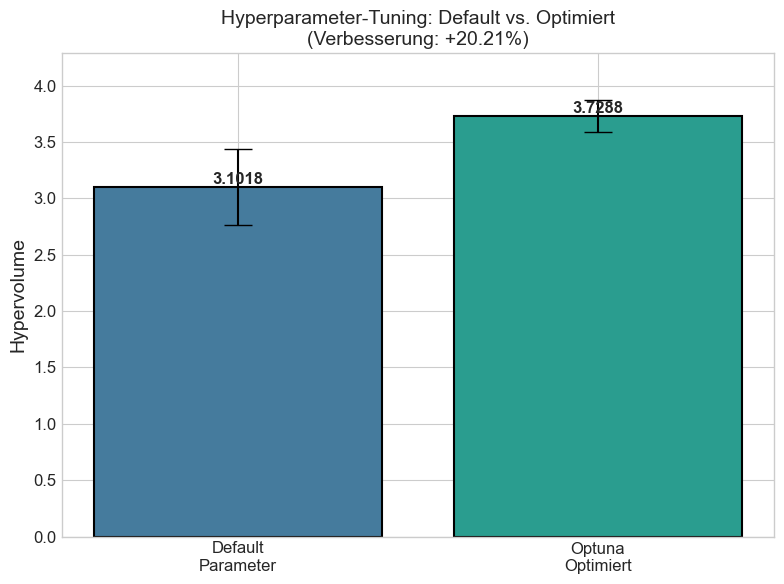

In [19]:
# Visualisierung des Vergleichs
fig, ax = plt.subplots(figsize=(8, 6))

x = ["Default\nParameter", "Optuna\nOptimiert"]
means = [default_hv_mean, optimized_hv_mean]
stds = [default_hv_std, optimized_hv_std]
colors = ["#457B9D", "#2A9D8F"]

bars = ax.bar(x, means, yerr=stds, capsize=10, color=colors, edgecolor='black', linewidth=1.5)

# Werte auf Balken
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
            f'{mean:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Hypervolume', fontsize=14)
ax.set_title(f'Hyperparameter-Tuning: Default vs. Optimiert\n(Verbesserung: {improvement:+.2f}%)', fontsize=14)
ax.set_ylim(0, max(means) * 1.15)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'optuna_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 10. Export der optimierten Konfiguration

In [20]:
# Speichere optimierte Konfiguration
optimized_config = {
    "algorithm": "NSGA-II",
    "tuning_method": "Optuna (TPE)",
    "n_trials": N_TRIALS,
    "best_hypervolume": float(study.best_value),
    "validated_hypervolume_mean": float(optimized_hv_mean),
    "validated_hypervolume_std": float(optimized_hv_std),
    "improvement_over_default_percent": float(improvement),
    "parameters": {
        "pop_size": int(best_params["pop_size"]),
        "eta_crossover": float(best_params["eta_crossover"]),
        "eta_mutation": float(best_params["eta_mutation"]),
        "crossover_prob": float(best_params["crossover_prob"])
    },
    "default_parameters": DEFAULT_PARAMS
}

with open(RESULTS_DIR / 'optuna_optimized_config.json', 'w') as f:
    json.dump(optimized_config, f, indent=2)

print(f"Optimierte Konfiguration gespeichert: {RESULTS_DIR / 'optuna_optimized_config.json'}")

Optimierte Konfiguration gespeichert: results/optuna_optimized_config.json


In [21]:
# Parameter-Tabelle für Präsentation
param_comparison = pd.DataFrame({
    "Parameter": ["pop_size", "eta_crossover", "eta_mutation", "crossover_prob"],
    "Default": [DEFAULT_PARAMS["pop_size"], DEFAULT_PARAMS["eta_crossover"], 
                DEFAULT_PARAMS["eta_mutation"], DEFAULT_PARAMS["crossover_prob"]],
    "Optimiert": [best_params["pop_size"], f"{best_params['eta_crossover']:.2f}", 
                  f"{best_params['eta_mutation']:.2f}", f"{best_params['crossover_prob']:.2f}"]
})

print("\nParameter-Vergleich für Präsentation:")
param_comparison


Parameter-Vergleich für Präsentation:


,Parameter,Default,Optimiert
0,pop_size,40.0,100
1,eta_crossover,15.0,23.33
2,eta_mutation,20.0,10.74
3,crossover_prob,0.9,0.92


---

## 11. Fazit & Interpretation

### Erkenntnisse aus dem Hyperparameter-Tuning

1. **Wichtigste Parameter:** (siehe Importance Plot)
   - Welcher Parameter hat den größten Einfluss auf den Hypervolume?
   
2. **Optimale Werte:**
   - Populationsgröße: Größer/kleiner als Default?
   - Crossover/Mutation: Exploration vs. Exploitation Balance

3. **Verbesserung:**
   - Prozentuale Verbesserung gegenüber Default-Parametern

### Empfehlung

Die optimierten Parameter sollten für zukünftige Experimente verwendet werden, wenn maximale Performance wichtiger ist als Vergleichbarkeit mit Standardliteratur.

### Code-Snippet für spätere Notebooks

```python
# Optimierte Parameter aus Optuna
with open('results/optuna_optimized_config.json', 'r') as f:
    optuna_config = json.load(f)
    
algorithm = NSGA2(
    pop_size=optuna_config['parameters']['pop_size'],
    crossover=SBX(
        prob=optuna_config['parameters']['crossover_prob'], 
        eta=optuna_config['parameters']['eta_crossover']
    ),
    mutation=PM(eta=optuna_config['parameters']['eta_mutation'])
)
```